In [1]:
import matplotlib.pyplot as plt
import numpy as np
import mat73
import scipy.signal as ss
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
from scipy import signal
plt.rcParams['font.size'] = 18

In [2]:
plt.rcParams['text.usetex'] =True
plt.rcParams['font.family'] = 'serif',
plt.rcParams['font.serif'] =  'Computer Modern'

In [6]:
cd D:

D:\


In [7]:
cd new_data_thalamus/

D:\new_data_thalamus


## Thalamo-cortical dataset

In [3]:
path = "C:/Users/Benedetta/Downloads/Barrel+Talamo/Barrel+Talamo"

In [4]:
#os.chdir(path)
import warnings
warnings.filterwarnings("ignore")

In [10]:
#### THALAMUS DATA
import os
import scipy.signal as ss
from scipy import signal
import mat73

w =  7
numf = 50
nrat = 0
start = int(input('start'))
nchan_c=27
nchan = 30
T=10
fs=25000


for rat in [nrat]:
    thalamus = 1
    for file in [os.listdir()[start:][rat]]:
        if file == 'Figs': continue
        print(os.getcwd(), file)
        data_dict = mat73.loadmat(file)
        data = data_dict['amplifier_data']
        if thalamus: stim = data_dict['adc_data'][0]
        if not thalamus: stim = data_dict['adc_data']
        indexes = (np.where(stim> 1.5)[0])[np.where(np.diff(np.where(stim> 1.5)[0])>1)]
        indexes = np.array(indexes.tolist() + [int(indexes[-1] + np.diff(indexes)[-1])]) - 125
        fs = 25000
        conv = 1/fs
        nyq = 0.5*fs
        low = 0.1/nyq 
        high = 50/nyq
        b,a = ss.butter(2,[low,high], "bandpass")
        sig = ss.filtfilt(b,a,data,axis = 1,)
        del data
        if thalamus:
            fs = 25000.0  # Sample frequency (Hz)
            f0 = 100.0  # Frequency to be removed from signal (Hz)
            Q = 30.0  # Quality factor
            # Design notch filter
            b, a = ss.iirnotch(f0, Q, fs)
            sig2 =  ss.filtfilt(b,a,sig,axis = 1)
        else:
            sig2 = sig
        del sig
        if thalamus:
            lfpTrials = []
            for r in range(1,len(indexes)-1):
                sigg = sig2[:nchan_c,indexes[r]-int(fs):indexes[r]+ int(fs*T)]
                lfpTrials.append(sigg)
            lfpTrials = np.array(lfpTrials)
            lfpTrials = np.delete(lfpTrials,[12,13,14,15,16,17,18,19],1)
        else:
            lfpTrials = []
            for r in range(1,len(indexes)-1):
                sigg = (sig2[:nchan,indexes[r]-int(fs):indexes[r]+ int(fs*T)])
                lfpTrials.append(sigg)
            lfpTrials = np.array(lfpTrials)
    

start 0


D:\new_data_thalamus Piezo_220131_114858.mat


In [11]:
sig_th2 = lfpTrials[:,10,:25000*4]
sig_th_cort2 = lfpTrials[:,17,:25000*4]

sig_th2 = sig_th2[:,np.newaxis,:]
sig_th_cort2 = sig_th_cort2[:,np.newaxis,:]
mat_th2 =[]

w =  7
numf = 50
fac = 10
fs = 25000/fac
for chan in [0]:
    for trial in range(sig_th2.shape[0]):
        sig  = signal.decimate(sig_th2[trial,chan,:],fac)
        freq = np.logspace(np.log10(1), np.log10(25), numf)
        widths = w*fs / (2*freq*np.pi)
        cwtm = signal.cwt(sig, signal.morlet2, widths, w=w)
        mat_th2.append(np.real((cwtm)*np.conjugate(cwtm))) 
mat_th2 = np.array(mat_th2)

mat_th_cort2 =[]
w =  7
numf = 50
fac = 10
fs = 25000/fac
for chan in [0]:
    for trial in range(sig_th2.shape[0]):
        sig  = signal.decimate(sig_th_cort2[trial,chan,:],fac) 
        freq = np.logspace(np.log10(1), np.log10(25), numf)
        widths = w*fs / (2*freq*np.pi)
        cwtm = signal.cwt(sig, signal.morlet2, widths, w=w)
        mat_th_cort2.append(np.real((cwtm)*np.conjugate(cwtm))) 
        
mat_th_cort2 = np.array(mat_th_cort2)
mat_th_cort2.shape

(28, 50, 10000)

In [12]:
del sigg, sig2, lfpTrials

## Loading other datasets

In [13]:
import os
import numpy as np
import scipy.signal as ss
import mat73

thalamus = True
if not thalamus:
    rat = 4
    file = os.listdir()[1:][rat]
    import mat73
    data_dict = mat73.loadmat(file)
    data = data_dict['amplifier_data']
    stim = data_dict['adc_data']
    indexes = (np.where(stim> 1.5)[0])[np.where(np.diff(np.where(stim> 1.5)[0])>1)]
    indexes = np.array(indexes.tolist() + [int(indexes[-1] + np.diff(indexes)[-1])]) - 125
    fs = 25000

if thalamus:
    file = os.listdir()[start:][rat]
    data_dict = mat73.loadmat(file)
    data = data_dict['amplifier_data']
    stim = data_dict['adc_data'][0]
    indexes = (np.where(stim> 1.5)[0])[np.where(np.diff(np.where(stim> 1.5)[0])>1)]
    indexes = np.array(indexes.tolist() + [int(indexes[-1] + np.diff(indexes)[-1])]) - 125
    fs = 25000


In [14]:
%load_ext autoreload
%autoreload 2

In [15]:
import sys
sys.path.append("C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Codes/Marianietal2026-PlosCompBio/Modules")

In [16]:
from functions import *

In [187]:
import os
import numpy as np
from scipy import signal as ss
from tqdm import tqdm 
import h5py

nTrials = 1
nchan_c = 27
nchan = 30
fs =25000
T = 10


r = 7
with h5py.File(f'{file}', 'r') as f:
    data_ds = f['amplifier_data'][indexes[r]:indexes[r]+ int(fs*T)]  
    #print(data_ds.shape)
    fs = f['sampling_frequency'][0][0]      
    b, a = ss.butter(2, [300, 3000], btype='bandpass', fs=fs)
    spikes = np.zeros((data_ds.shape[1],data_ds.shape[0]), dtype=np.float32)
    for i in tqdm(range(spikes.shape[0])):
        spikes[i, :] = ss.filtfilt(b, a,data_ds[:, i].astype(np.float32),)

    
### detrending
spikes = (spikes - np.mean(spikes,0))
#del spikes_memmap
spikesTrials = []
if not thalamus:
    for r in range(nTrials):
        spikesTrials.append(spikes[:nchan_c,:])
    spikesTrials = np.array(spikesTrials)
else:
    spikes = (spikes[:nchan])    
    for r in range(nTrials):
        spikesTrials.append(spikes[:,:])
    spikesTrials = np.array(spikesTrials)


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:00<00:00, 127.43it/s]


In [55]:
data_ds[:,:].shape[0]/25000

10.0

In [188]:

import emd
fs = 25000
f0 = 100.0  # Frequency to be removed from signal (Hz)
Q = 30.0  # Quality factor
nyq = 0.5*fs
low = 1/nyq
high = 50/nyq
b,a = ss.butter(2,[low,high], "bandpass")
# Design notch filter
b2, a2 = ss.iirnotch(f0, Q, fs)
#print(sig2.shape)
#r=7
sig3 = ss.filtfilt(b,a,data_ds[:,:],axis =0)
print(sig3.shape)
sig3 = ss.filtfilt(b2,a2,sig3[:,:],axis = 0)
#print(sig3.shape)

if thalamus:
    #print(sig3.shape)

    sig3 = (sig3[:,:nchan])
    #print(sig3.shape)
    lfpTrials = []
    lfpTrials.append(sig3[:,:].T)    
    
if not thalamus:
    sig3 = sig3[:,:nchan_c]
    lfpTrials = []
    lfpTrials.append(sig3[:,:].T)          
lfpTrials = np.array(lfpTrials)


(250000, 32)


In [57]:
lfpTrials.shape, data_ds.shape, data.shape

((1, 30, 250000), (250000, 32), (32, 7500032))

In [189]:
nch = spikesTrials.shape[1]
num = spikesTrials.shape[0]
binspikes =  np.zeros((num,nch,spikesTrials.shape[2]), dtype = int)
soglia = 4
for r in range(num):
    for ch in range(nch):
        binspikes[r,ch,:] = findpeaks(spikesTrials[r,ch,:],Thres(soglia,spikesTrials[r,ch,:]),"neg", dist = 10)


In [59]:
binspikes.shape, lfpTrials.shape

((1, 30, 250000), (1, 30, 250000))

# Figure 1

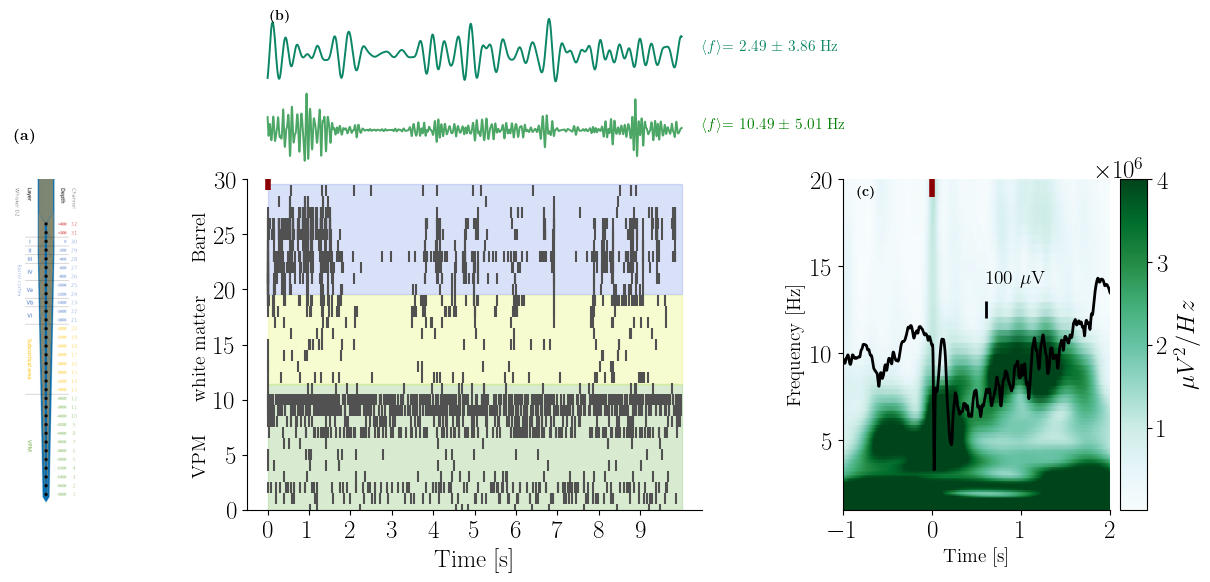

In [61]:
from matplotlib import cm
uptrial = 10
pos = []
s = 0#  7
trial=s

plt.rcParams['axes.spines.top']= False
plt.rcParams['axes.spines.right']= False

for g in range(binspikes[trial].shape[0]):
    pos.append(np.where(binspikes[trial,g]>0)[0])
pos = np.asarray(pos)
fig= plt.figure(figsize = (15,3.5*2))


gs = fig.add_gridspec(8,5, width_ratios = [0.8,0.4,3.,0.4,2.],
                      height_ratios = [0.4,0.4,0.4,1,1,1,1,1])


path = 'C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Thalamus/2024 work'

ax00 = fig.add_subplot(gs[4:8,0])
ax00.annotate('\\textbf{(a)}', size = 11,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05,1.12), textcoords='axes fraction')
ax00.axis('off')
ax00.imshow(plt.imread(os.path.join(path,"probe_new.png")),)

ax00 = fig.add_subplot(gs[4:8, 2])
ax00.eventplot(pos, colors =cm.Greys(0.75));
ax00.set_xticks(np.arange(0,fs*10,fs))
ax00.set_xticklabels(np.array(np.arange(0,fs*10,fs)/fs, dtype =int))
ax00.set_xlabel('Time [s]')
ax00.set_ylabel('Channels')
ax00.axvspan(0,T*fs,0.,0.+0.380,color = cm.get_cmap('summer')(0.5), alpha =.3)
ax00.axvspan(0,T*fs,0.382,0.4+0.25,color = cm.get_cmap('summer')(0.9), alpha =.3)
ax00.axvspan(0,T*fs,0.4+0.252,0.4+0.252+0.3333,color = 'royalblue', alpha =.2)
ax00.vlines(0,29,30,color = 'darkred', lw = 4)
ax00.set_ylabel(r" VPM \hspace{0.5cm} white matter \hspace{0.5cm} Barrel", fontsize =14)
ax00.set_ylim(0,30)


ax00 = fig.add_subplot(gs[1:4, 2])
ax00.annotate('\\textbf{(b)}', size = 10,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05,0.95), textcoords='axes fraction')
times = np.arange(0,fs*T,1)/fs
channel=25
v = emd.sift.mask_sift(lfpTrials[s,channel,:], mask_freqs= 30./fs, max_imfs=5, )
IP_, IF_, IA_ = emd.spectra.frequency_transform(v[:,3] + v[:,4], fs, 'nht')
IP, IF, IA = emd.spectra.frequency_transform(v, fs, 'nht')
ax00.plot(times, ( + v[:,3])*0.02+10, color = cm.get_cmap('summer')(0.05),lw= 1.4)
ax00.plot(times, v[:,1]*0.02, color = cm.get_cmap('summer')(0.3), lw=1.4)
ax00.set_xticks([])
ax00.axis('off')
value1, value2 = round(IF[:,1].mean(),2),round(IF[:,1].std(),2)
value3, value4 = round(IF_.mean(),2),round(IF_.std(),2)
ax00.annotate(r'$\langle f \rangle$'+f'= {value1} $\pm$ {value2} Hz', size = 11,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(1,0.25), textcoords='axes fraction', color ='green')
ax00.annotate(r'$\langle f  \rangle$'+f'= {value3} $\pm$ {value4} Hz', size = 11,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(1,0.75), textcoords='axes fraction', color = cm.get_cmap('summer')(0.05) )

axn = fig.add_subplot(gs[4:8,4])
axn.annotate('\\textbf{(c)}', size = 10,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05,0.95), textcoords='axes fraction')
fac = 10
sec =4
t = np.arange(0,int(fs/fac)*sec,1)/int(fs/fac) - 1
t_ = np.arange(0,int(fs/1)*sec,1)/int(fs/1) - 1
im = axn.pcolormesh(t[:int(fs/fac*(sec-1))], freq,np.mean(mat_th_cort2[:uptrial,:,:int(fs/fac*(sec-1))],0), cmap='BuGn', shading='gouraud', vmax =4e6)
axn.set_ylabel(r'Frequency [Hz]',fontsize = 14)
axn.text(0.6,13+1*100*0.01,r'100 $\mu$V', fontsize = 14)
axn.vlines(0.6,12,12+1*100*0.01, color = 'black',lw = 2)
axn.set_ylim(1,20)
axn.set_xlim(-1,2)
axn.plot(t_[:int(fs*(sec-1))],np.mean(sig_th_cort2[:uptrial,0,:int(fs*(sec-1))],0)*0.01 + 10, color ='black', lw = 2)
axn.vlines(0,19,20,color = 'darkred', lw = 4)
axn.set_xlabel(r'Time [s]',fontsize = 14)

divider = make_axes_locatable(axn)
cax = divider.append_axes('right', size='10%', pad=0.1)
fig.colorbar(im, cax=cax, label =r'$\mu V^2/Hz$');



In [65]:
sample_rate =fs

In [18]:
from avalanches_functions import *

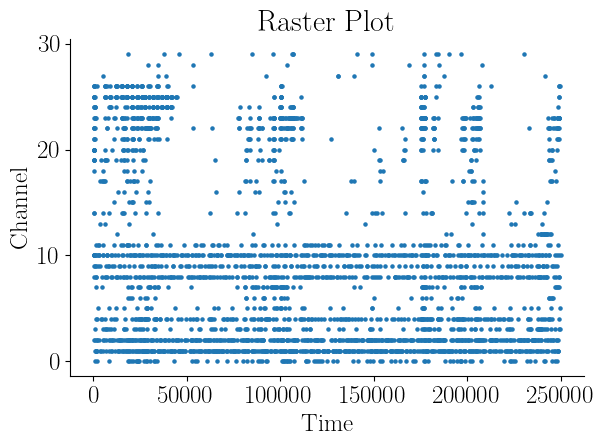

In [29]:
simple_raster_plot(binspikes[0].T)

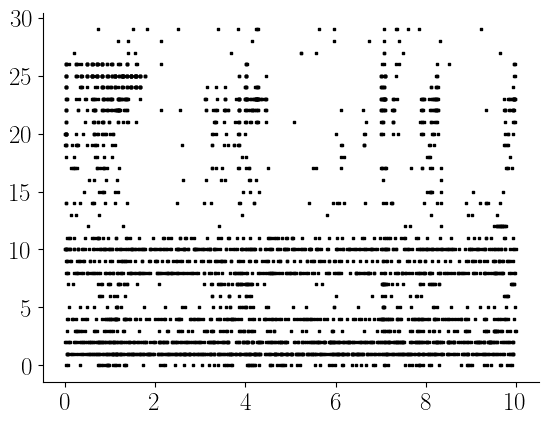

In [32]:
fig,ax = plt.subplots(1,1)

RasterPlot(binspikes[0].T, ax, 4e-5)

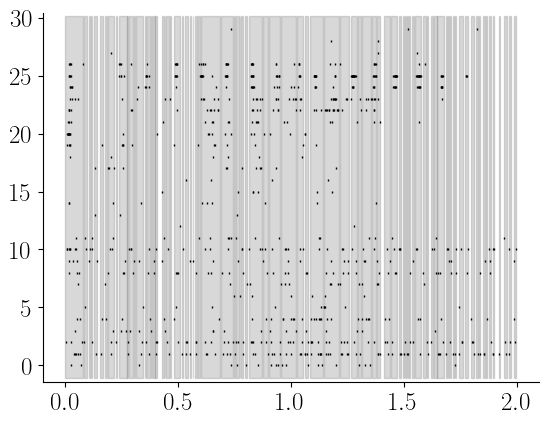

In [40]:
#fig,ax = plt.subplots(1,1)

RasterPlot2(binspikes[0,:,:25000*2].T, 100,fs = 25000);

10.30023218606089 3.1742023590443833
10.30023218606089 3.1742023590443833


Text(1, 0.75, '$\\langle f  \\rangle$= 3.1 $\\pm$ 7.32 Hz')

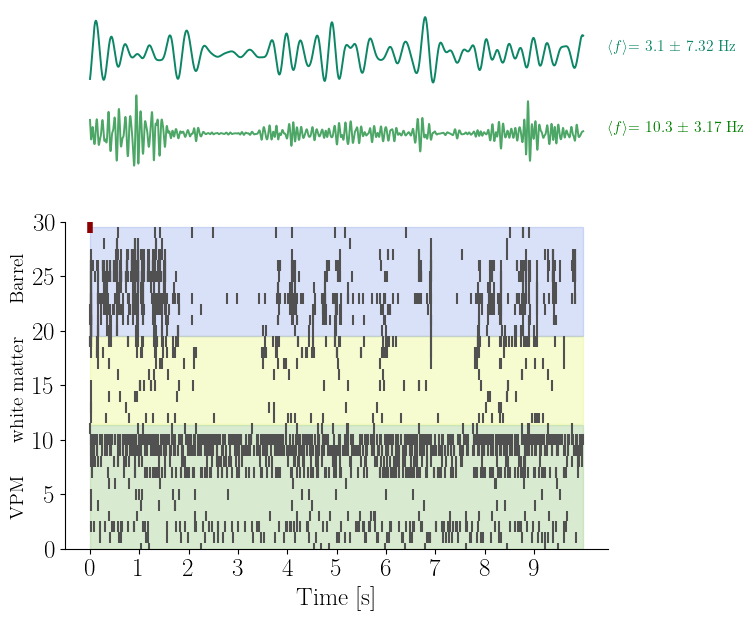

In [80]:
#fig, ax00 =plt.subplots(1,1)


fig= plt.figure(figsize = (7,7))

gs = fig.add_gridspec(2,1, width_ratios = [1], height_ratios = [0.4,0.8])#,0.4,1,1,1,1,1])

ax00 = fig.add_subplot(gs[1,0])

path = 'C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Thalamus/2024 work'


ax00.eventplot(pos, colors =cm.Greys(0.75));
ax00.set_xticks(np.arange(0,fs*10,fs))
ax00.set_xticklabels(np.array(np.arange(0,fs*10,fs)/fs, dtype =int))
ax00.set_xlabel('Time [s]')
ax00.set_ylabel('Channels')
ax00.axvspan(0,T*fs,0.,0.+0.380,color = cm.get_cmap('summer')(0.5), alpha =.3)
ax00.axvspan(0,T*fs,0.382,0.4+0.25,color = cm.get_cmap('summer')(0.9), alpha =.3)
ax00.axvspan(0,T*fs,0.4+0.252,0.4+0.252+0.3333,color = 'royalblue', alpha =.2)
ax00.vlines(0,29,30,color = 'darkred', lw = 4)
ax00.set_ylabel(r" VPM \hspace{0.5cm} white matter \hspace{0.5cm} Barrel", fontsize =14)
ax00.set_ylim(0,30)


ax00 = fig.add_subplot(gs[0,0])

#ax00.annotate('\\textbf{(b)}', size = 10,
 #                xy=(1, 1), xycoords='axes fraction',
  #               xytext=(0.05,0.95), textcoords='axes fraction')
times = np.arange(0,fs*T,1)/fs
channel=26


v = emd.sift.mask_sift(lfpTrials[s,channel,:], mask_freqs= 30./fs, max_imfs=5, )
imf = v
IP_, IF_, IA_ = emd.spectra.frequency_transform(v[:,3] + v[:,4], fs, 'nht')
IP, IF, IA = emd.spectra.frequency_transform(v, fs, 'nht')
ax00.plot(times, ( + v[:,3])*0.02+10, color = cm.get_cmap('summer')(0.05),lw= 1.4)
ax00.plot(times, v[:,1]*0.02, color = cm.get_cmap('summer')(0.3), lw=1.4)
ax00.set_xticks([])
ax00.axis('off')
value1, value2 = round(IF[:,1].mean(),2),round(IF[:,1].std(),2)


IP, IF, IA = emd.spectra.frequency_transform(imf, sample_rate, 'nht')
value_imf = 1
mask = IF[:,value_imf] > 0

values = IF[:,value_imf]
#[mask]
weights = IA[:,value_imf]
#[mask]
#weights = np.ones(values.shape[0])
# media pesata
mean = np.average(values, weights=weights)

# std pesata (population)
variance = np.average((values - mean)**2, weights=weights)
std = np.sqrt(variance)


print(mean,std)

value3, value4 = round(IF_.mean(),2),round(IF_.std(),2)



IP, IF, IA = emd.spectra.frequency_transform(imf, sample_rate, 'nht')
value_imf = 3
mask = IF[:,value_imf] > 0

values = IF[:,value_imf]
#[mask]
weights = IA[:,value_imf]
#[mask]
#weights = np.ones(values.shape[0])
# media pesata
mean_ = np.average(values, weights=weights)

# std pesata (population)
variance_ = np.average((values - mean)**2, weights=weights)
std_ = np.sqrt(variance_)
print(mean,std)
ax00.annotate(r'$\langle f \rangle$'+f'= {round(mean,2)} $\pm$ {round(std,2)} Hz', size = 11,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(1,0.25), textcoords='axes fraction', color ='green')
ax00.annotate(r'$\langle f  \rangle$'+f'= {round(mean_,2)} $\pm$ {round(std_,2)} Hz', size = 11,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(1,0.75), textcoords='axes fraction', color = cm.get_cmap('summer')(0.05) )


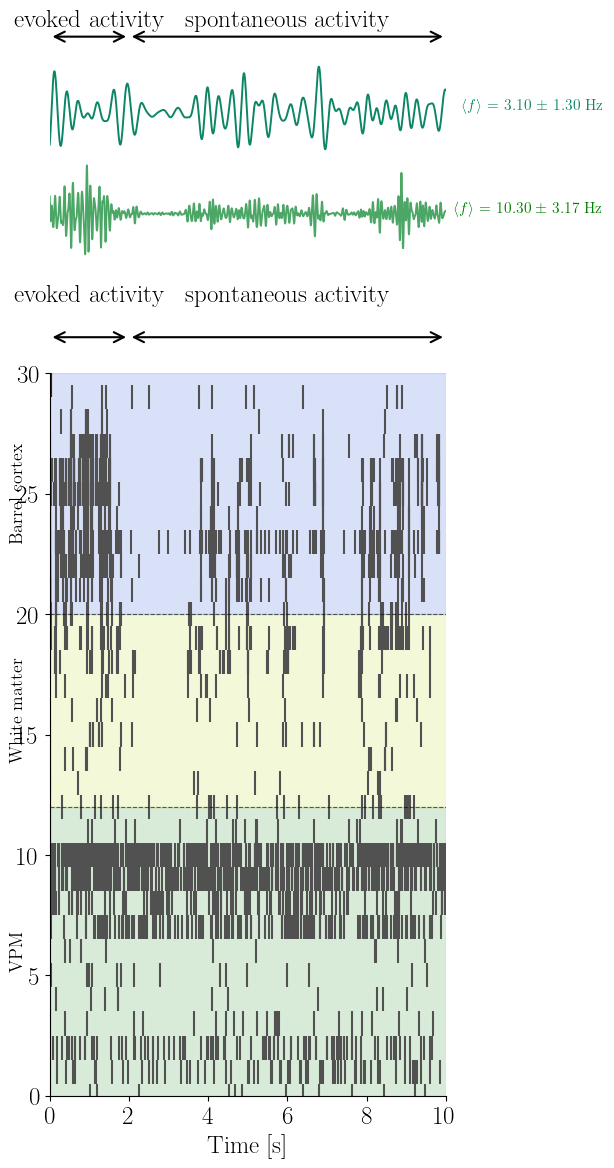

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# =========================
# PARAMETRI
# =========================
t_split = 2
t_end = T

times = np.arange(0, fs*T) / fs
pos_sec = [p/fs for p in pos]

# =========================
# FIGURA
# =========================
fig = plt.figure(figsize=(7,12))
gs = fig.add_gridspec(2,1, height_ratios=[0.4, 1.4])

# =========================
# 🔻 PANNELLO SOTTO (RASTER)
# =========================
ax_bottom = fig.add_subplot(gs[1,0])

ax_bottom.eventplot(pos_sec, colors=cm.Greys(0.75))

ax_bottom.set_xlim(0, t_end)
ax_bottom.set_ylim(0, 30)
ax_bottom.set_xlabel('Time [s]')

# =========================
# REGIONI ANATOMICHE
# =========================
ax_bottom.axhspan(0, 12, color=cm.get_cmap('summer')(0.4), alpha=0.25)
ax_bottom.axhspan(12, 20, color=cm.get_cmap('summer')(0.8), alpha=0.25)
ax_bottom.axhspan(20, 30, color='royalblue', alpha=0.2)

ax_bottom.hlines([12,20], 0, t_end, colors='k', linestyles='dashed', lw=0.8, alpha=0.6)

# =========================
# LABEL SINISTRA ALLINEATA
# =========================
ax_bottom.set_ylabel('')
plt.subplots_adjust(left=0.18)

centers = [6, 16, 25]
labels = ['VPM', 'White matter', 'Barrel cortex']

for y, lab in zip(centers, labels):
    ax_bottom.text(-0.08, y, lab,
                   transform=ax_bottom.get_yaxis_transform(),
                   rotation=90, va='center', ha='center', fontsize=13)

# =========================
# STIMOLO
# =========================
ax_bottom.vlines(0, 29, 30, color='darkred', lw=3)

# =========================
# FRECCE SOTTO
# =========================
y_arrow = 1.05

ax_bottom.annotate('', xy=(t_split, y_arrow), xytext=(0, y_arrow),
                   xycoords=('data','axes fraction'),
                   arrowprops=dict(arrowstyle='<->', lw=1.5))

ax_bottom.text(t_split/2, y_arrow+0.05, 'evoked activity',
               ha='center', transform=ax_bottom.get_xaxis_transform())

ax_bottom.annotate('', xy=(t_end, y_arrow), xytext=(t_split, y_arrow),
                   xycoords=('data','axes fraction'),
                   arrowprops=dict(arrowstyle='<->', lw=1.5))

ax_bottom.text((t_split+t_end)/2, y_arrow+0.05, 'spontaneous activity',
               ha='center', transform=ax_bottom.get_xaxis_transform())


# =========================
# 🔺 PANNELLO SOPRA (IMF + FREQUENZE)
# =========================
ax_top = fig.add_subplot(gs[0,0])

channel = 25

v = emd.sift.mask_sift(
    lfpTrials[0,channel,:],
    mask_freqs=30./fs,
    max_imfs=5
)

# segnali
ax_top.plot(times, v[:,3]*0.02 + 10,
            color=cm.get_cmap('summer')(0.05), lw=1.4)

ax_top.plot(times, v[:,1]*0.02,
            color=cm.get_cmap('summer')(0.3), lw=1.4)

ax_top.set_xlim(0, t_end)
ax_top.axis('off')

# =========================
# FREQUENZE (COME AVEVI)
# =========================
IP, IF, IA = emd.spectra.frequency_transform(v, fs, 'nht')

# IMF 1
values = IF[:,1]
weights = IA[:,1]

mean = np.average(values, weights=weights)
std = np.sqrt(np.average((values-mean)**2, weights=weights))

# IMF 3
values_ = IF[:,3]
weights_ = IA[:,3]

mean_ = np.average(values_, weights=weights_)
std_ = np.sqrt(np.average((values_-mean_)**2, weights=weights_))

# annotazioni
ax_top.text(1.4, 0.25,
            rf'$\langle f \rangle$ = {mean:.2f} $\pm$ {std:.2f} Hz',
            transform=ax_top.transAxes,
            ha='right', color='green', fontsize=11)

ax_top.text(1.4, 0.75,
            rf'$\langle f \rangle$ = {mean_:.2f} $\pm$ {std_:.2f} Hz',
            transform=ax_top.transAxes,
            ha='right',
            color=cm.get_cmap('summer')(0.05),
            fontsize=11)

# =========================
# FRECCE SOPRA
# =========================
y_arrow = 1.1

ax_top.annotate('', xy=(t_split, y_arrow), xytext=(0, y_arrow),
                xycoords=('data','axes fraction'),
                arrowprops=dict(arrowstyle='<->', lw=1.5))

ax_top.text(t_split/2, y_arrow+0.05, 'evoked activity',
            ha='center', transform=ax_top.get_xaxis_transform())

ax_top.annotate('', xy=(t_end, y_arrow), xytext=(t_split, y_arrow),
                xycoords=('data','axes fraction'),
                arrowprops=dict(arrowstyle='<->', lw=1.5))

ax_top.text((t_split+t_end)/2, y_arrow+0.05, 'spontaneous activity',
            ha='center', transform=ax_top.get_xaxis_transform())

# =========================
# FINAL
# =========================
plt.tight_layout()
plt.show()

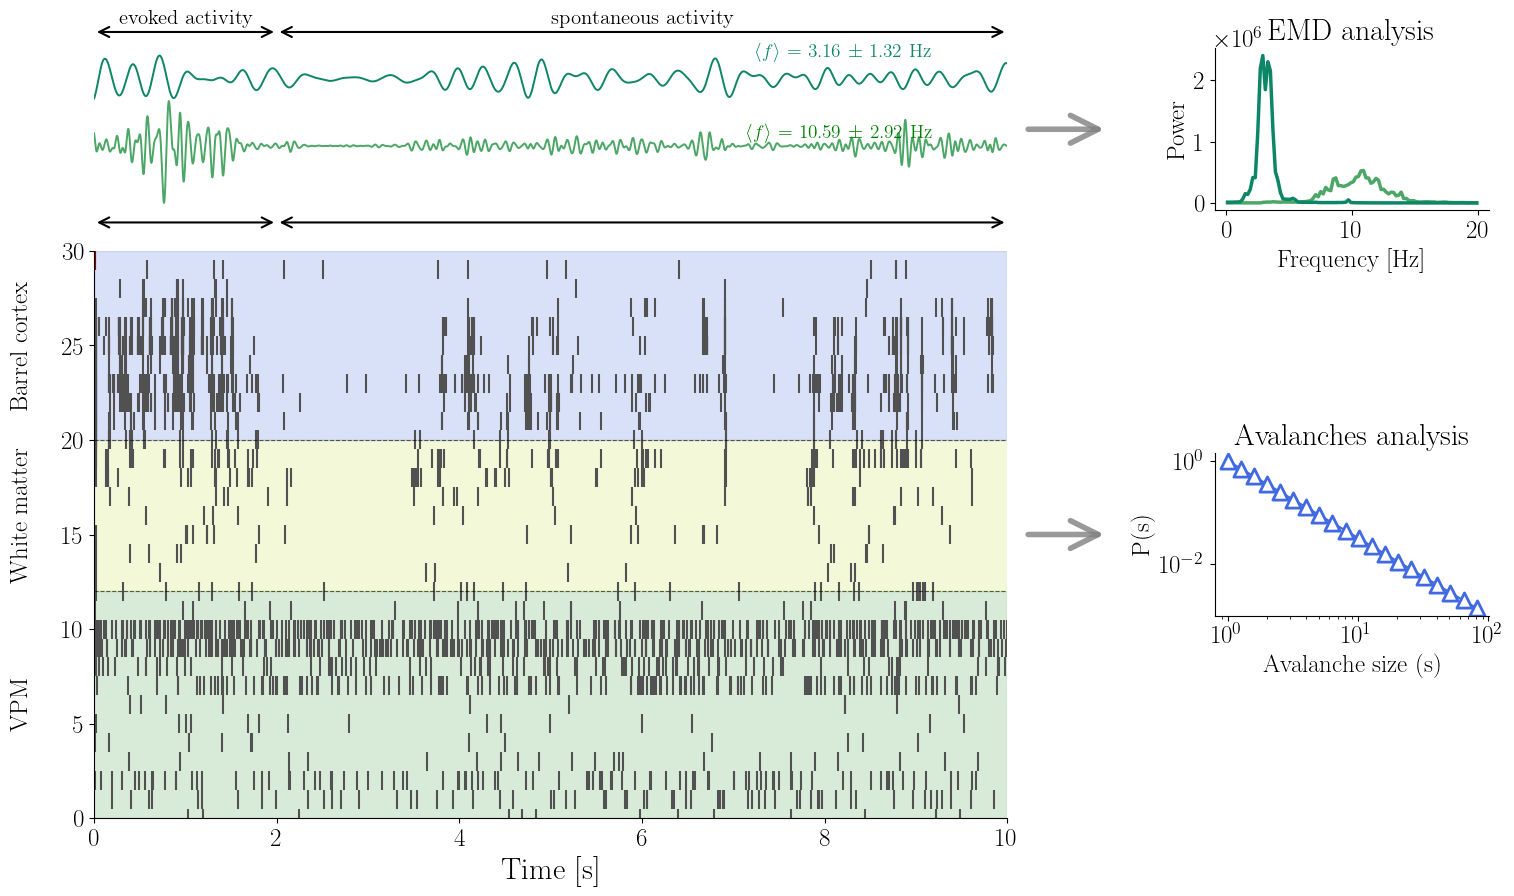

In [193]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import FancyArrowPatch

# =========================
# PARAMETRI
# =========================
t_split = 2
t_end = T
pos =[]
for g in range(binspikes[trial].shape[0]):
    pos.append(np.where(binspikes[trial,g]>0)[0])
pos = np.asarray(pos)
times = np.arange(0, fs*T) / fs
pos_sec = [p/fs for p in pos]

# =========================
# FIGURA
# =========================
fig = plt.figure(figsize=(18,10))

# 👉 COLONNA DESTRA: 3 SLOT VERTICALI
gs = fig.add_gridspec(
    4, 2,
    height_ratios=[1, 1, 1.0,1.0],
    width_ratios=[2.0, 0.6],
    wspace=0.35,
    hspace=0.25
)

# ============================================================
# 🔺 TOP SINISTRA (OSCILLAZIONI)
# ============================================================
ax_top = fig.add_subplot(gs[0,0])

channel = 26

v = emd.sift.mask_sift(
    lfpTrials[0,channel,:],
    mask_freqs=30./fs,
    max_imfs=5
)

ax_top.plot(times, v[:,3]*0.02 + 10,
            color=cm.get_cmap('summer')(0.05), lw=1.4)

ax_top.plot(times, v[:,1]*0.02,
            color=cm.get_cmap('summer')(0.3), lw=1.4)

ax_top.set_xlim(0, t_end)
ax_top.axis('off')

# =========================
# FREQUENZE
# =========================
IP, IF, IA = emd.spectra.frequency_transform(v, fs, 'nht')

mean = np.average(IF[:,1], weights=IA[:,1])
std = np.sqrt(np.average((IF[:,1]-mean)**2, weights=IA[:,1]))

mean_ = np.average(IF[:,3], weights=IA[:,3])
std_ = np.sqrt(np.average((IF[:,3]-mean_)**2, weights=IA[:,3]))

ax_top.text(0.92, 0.45,
            rf'$\langle f \rangle$ = {mean:.2f} $\pm$ {std:.2f} Hz',
            transform=ax_top.transAxes,
            ha='right', color='green', fontsize=14)

ax_top.text(0.92, 0.95,
            rf'$\langle f \rangle$ = {mean_:.2f} $\pm$ {std_:.2f} Hz',
            transform=ax_top.transAxes,
            ha='right',
            color=cm.get_cmap('summer')(0.05),
            fontsize=14)

# ============================================================
# 🔻 BOTTOM SINISTRA (RASTER)
# ============================================================
ax_bottom = fig.add_subplot(gs[1:,0])

ax_bottom.eventplot(pos_sec, colors=cm.Greys(0.75))

ax_bottom.set_xlim(0, t_end)
ax_bottom.set_ylim(0, 30)
ax_bottom.set_xlabel('Time [s]', fontsize =22)

ax_bottom.axhspan(0, 12, color=cm.get_cmap('summer')(0.4), alpha=0.25)
ax_bottom.axhspan(12, 20, color=cm.get_cmap('summer')(0.8), alpha=0.25)
ax_bottom.axhspan(20, 30, color='royalblue', alpha=0.2)

ax_bottom.hlines([12,20], 0, t_end,
                 colors='k', linestyles='dashed', lw=0.8, alpha=0.6)

centers = [6, 16, 25]
labels = ['VPM', 'White matter', 'Barrel cortex']

for y, lab in zip(centers, labels):
    ax_bottom.text(-0.08, y, lab,
                   transform=ax_bottom.get_yaxis_transform(),
                   rotation=90, va='center', ha='center', fontsize=18)

ax_bottom.vlines(0, 29, 30, color='darkred', lw=3)

# ============================================================
# 🔺 HHT (TOP DESTRA)
# ============================================================
ax_hht = fig.add_subplot(gs[0,1])

hht_f, spec = emd.spectra.hilberthuang(
    IF, IA,
    freq_range,
    mode='density',
    sum_imfs=False,
    sum_time=True
)

ax_hht.plot(hht_f, spec[:,1],
            lw=2.5,
            color=cm.get_cmap('summer')(0.3))

ax_hht.plot(hht_f, spec[:,3],
            lw=2.5,
            color=cm.get_cmap('summer')(0.05))

ax_hht.set_title('EMD analysis',)
ax_hht.set_xlabel('Frequency [Hz]')
ax_hht.set_ylabel('Power')

# ============================================================
# 🔻 AVALANCHES (CENTRO DESTRA — PICCOLO)
# ============================================================
ax_av = fig.add_subplot(gs[2,1])   # 👈 SOLO SLOT CENTRALE

s = np.logspace(0, 2, 200)[::10]
alpha = 1.5
ns = s**(-alpha)

ax_av.plot(s, ns,'-',
             color='royalblue'
            ,zorder=1 )

ax_av.scatter(s, ns,marker='^',s=120,facecolor='white',edgecolor='royalblue',  linewidths=2)



ax_av.set_yscale('log')
ax_av.set_xscale('log')


ax_av.set_xlabel('Avalanche size (s)')
ax_av.set_ylabel('P(s)')
ax_av.set_title('Avalanches analysis')

#ax_av.grid(True, which='both', alpha=0.2)

# ============================================================
# 🔗 FRECCIA 1: OSCILLAZIONI → HHT
# ============================================================
pos_top = ax_top.get_position()
pos_hht = ax_hht.get_position()

arrow1 = FancyArrowPatch(
    (pos_top.x1+0.01, (pos_top.y0 + pos_top.y1)/2),
    (pos_hht.x0-0.06, (pos_hht.y0 + pos_hht.y1)/2),
    transform=fig.transFigure,
    arrowstyle='->',
    lw=4,
    color='grey',
    mutation_scale=50,
    alpha=0.8
)

fig.add_artist(arrow1)

# ============================================================
# 🔗 FRECCIA 2: RASTER → AVALANCHES
# ============================================================
pos_raster = ax_bottom.get_position()
pos_av = ax_av.get_position()

arrow2 = FancyArrowPatch(
    (pos_raster.x1 +0.01, (pos_raster.y0 + pos_raster.y1)/2),
    (pos_av.x0-0.06, (pos_av.y0 + pos_av.y1)/2),
    transform=fig.transFigure,
    arrowstyle='->',
    lw=4,
    color='grey',
    mutation_scale=50,
    alpha=0.8
)
# =========================
# FRECCE EVOKED / SPONTANEOUS (TOP)
# =========================
y_arrow = 1.1

ax_top.annotate(
    '', xy=(t_split, y_arrow), xytext=(0, y_arrow),
    xycoords=('data','axes fraction'),
    arrowprops=dict(arrowstyle='<->', lw=1.5, color='black')
)

ax_top.text(
    t_split/2, y_arrow+0.05,
    'evoked activity',fontsize =15,
    ha='center',
    transform=ax_top.get_xaxis_transform()
)

ax_top.annotate(
    '', xy=(t_end, y_arrow), xytext=(t_split, y_arrow),
    xycoords=('data','axes fraction'),
    arrowprops=dict(arrowstyle='<->', lw=1.5, color='black')
)

ax_top.text(
    (t_split+t_end)/2, y_arrow+0.05,
    'spontaneous activity',
    ha='center',fontsize =15,
    transform=ax_top.get_xaxis_transform()
)

# =========================
# FRECCE EVOKED / SPONTANEOUS (BOTTOM)
# =========================
y_arrow = 1.05

ax_bottom.annotate(
    '', xy=(t_split, y_arrow), xytext=(0, y_arrow),
    xycoords=('data','axes fraction'),
    arrowprops=dict(arrowstyle='<->', lw=1.5, color='black')
)

ax_bottom.text(
    t_split/2, y_arrow+0.05,
    '',
    ha='center',
    transform=ax_bottom.get_xaxis_transform()
)

ax_bottom.annotate(
    '', xy=(t_end, y_arrow), xytext=(t_split, y_arrow),
    xycoords=('data','axes fraction'),
    arrowprops=dict(arrowstyle='<->', lw=1.5, color='black')
)

ax_bottom.text(
    (t_split+t_end)/2, y_arrow+0.05,
    '',
    ha='center',
    transform=ax_bottom.get_xaxis_transform()
)
fig.add_artist(arrow2)

# =========================
# FINAL
# =========================
plt.tight_layout()
# channel 26 di rat  0 su memoria esterna
path_fig = "C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Thalamus/Paper Figures/"
#plt.savefig(path_fig + 'Figura 1.jpg', dpi = 300, bbox_inches ='tight')
#plt.savefig(path_fig + 'Figura 1.tif', dpi = 300, bbox_inches ='tight')


In [177]:
plt.rcParams['font.size']=18

In [180]:
trial

0